In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Exploratory Data Analysis(EDA)

In [2]:
## loading data set
df = pd.read_excel(r"World_development_mesurement.xlsx")

In [3]:
df

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


In [4]:
df.shape

(2704, 25)

In [5]:
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [7]:
# List of columns to convert
columns_to_convert = ['Business Tax Rate','GDP','Health Exp/Capita' ,'Tourism Inbound', 'Tourism Outbound']

# Clean and convert the columns
for col in columns_to_convert:
    # Remove '$', '%' and convert to numeric 
    df[col] = df[col].astype(str).str.replace('[$,]', '', regex=True).str.replace('[%,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Display the data types after conversion
display(df[columns_to_convert].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Business Tax Rate  1423 non-null   float64
 1   GDP                2494 non-null   float64
 2   Health Exp/Capita  2395 non-null   float64
 3   Tourism Inbound    2336 non-null   float64
 4   Tourism Outbound   2233 non-null   float64
dtypes: float64(5)
memory usage: 105.8 KB


None

In [8]:
df.dtypes

Birth Rate                float64
Business Tax Rate         float64
CO2 Emissions             float64
Country                    object
Days to Start Business    float64
Ease of Business          float64
Energy Usage              float64
GDP                       float64
Health Exp % GDP          float64
Health Exp/Capita         float64
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Number of Records           int64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total            int64
Population Urban          float64
Tourism Inbound           float64
Tourism Outbound          float64
dtype: object

In [9]:
# finding missing values
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [10]:
# Handling missing values
df = df.dropna(thresh=len(df)*0.7, axis=1)
# Fill missing values in numerical columns with the mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())


In [11]:
df.isnull().sum()

Birth Rate                0
CO2 Emissions             0
Country                   0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Infant Mortality Rate     0
Internet Usage            0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
display(numerical_cols)

Index(['Birth Rate', 'CO2 Emissions', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Infant Mortality Rate', 'Internet Usage',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [14]:
df.describe()

,Birth Rate,CO2 Emissions,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
count,2704.000000,2.704000e+03,2.704000e+03,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.0,2704.000000,2704.000000,2704.000000,2.704000e+03,2704.000000,2.704000e+03,2.704000e+03
mean,0.022715,1.423071e+05,2.638540e+11,0.064170,801.397077,0.032813,0.239747,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953,4.939320e+09,4.729435e+09
std,0.011086,5.459901e+05,1.085131e+12,0.024774,1386.672409,0.028490,0.251670,10.435395,9.150937,0.459751,0.0,0.102148,0.066765,0.047482,1.242894e+08,0.244712,1.287363e+10,1.205649e+10
min,0.007000,7.000000e+00,6.310127e+07,0.008000,2.000000,0.002000,0.000000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000,7.000000e+05,2.000000e+05
25%,0.013000,2.237000e+03,4.113748e+09,0.048000,58.000000,0.010000,0.000000,65.000000,61.000000,0.200000,1.0,0.210000,0.565000,0.034000,8.783360e+05,0.357750,1.860000e+08,1.470000e+08
50%,0.021000,2.990450e+04,1.972267e+10,0.064000,262.500000,0.025000,0.200000,74.000000,68.000000,0.578124,1.0,0.303051,0.631000,0.059000,5.800324e+06,0.562953,1.103500e+09,8.255000e+08
75%,0.030000,1.423071e+05,1.890042e+11,0.076000,801.397077,0.049000,0.400000,79.000000,73.000000,0.900000,1.0,0.395000,0.673000,0.105000,2.014089e+07,0.763000,4.939320e+09,4.729435e+09
max,0.053000,8.286892e+06,1.624460e+13,0.225000,9908.000000,0.141000,1.000000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000,2.000920e+11,1.265730e+11


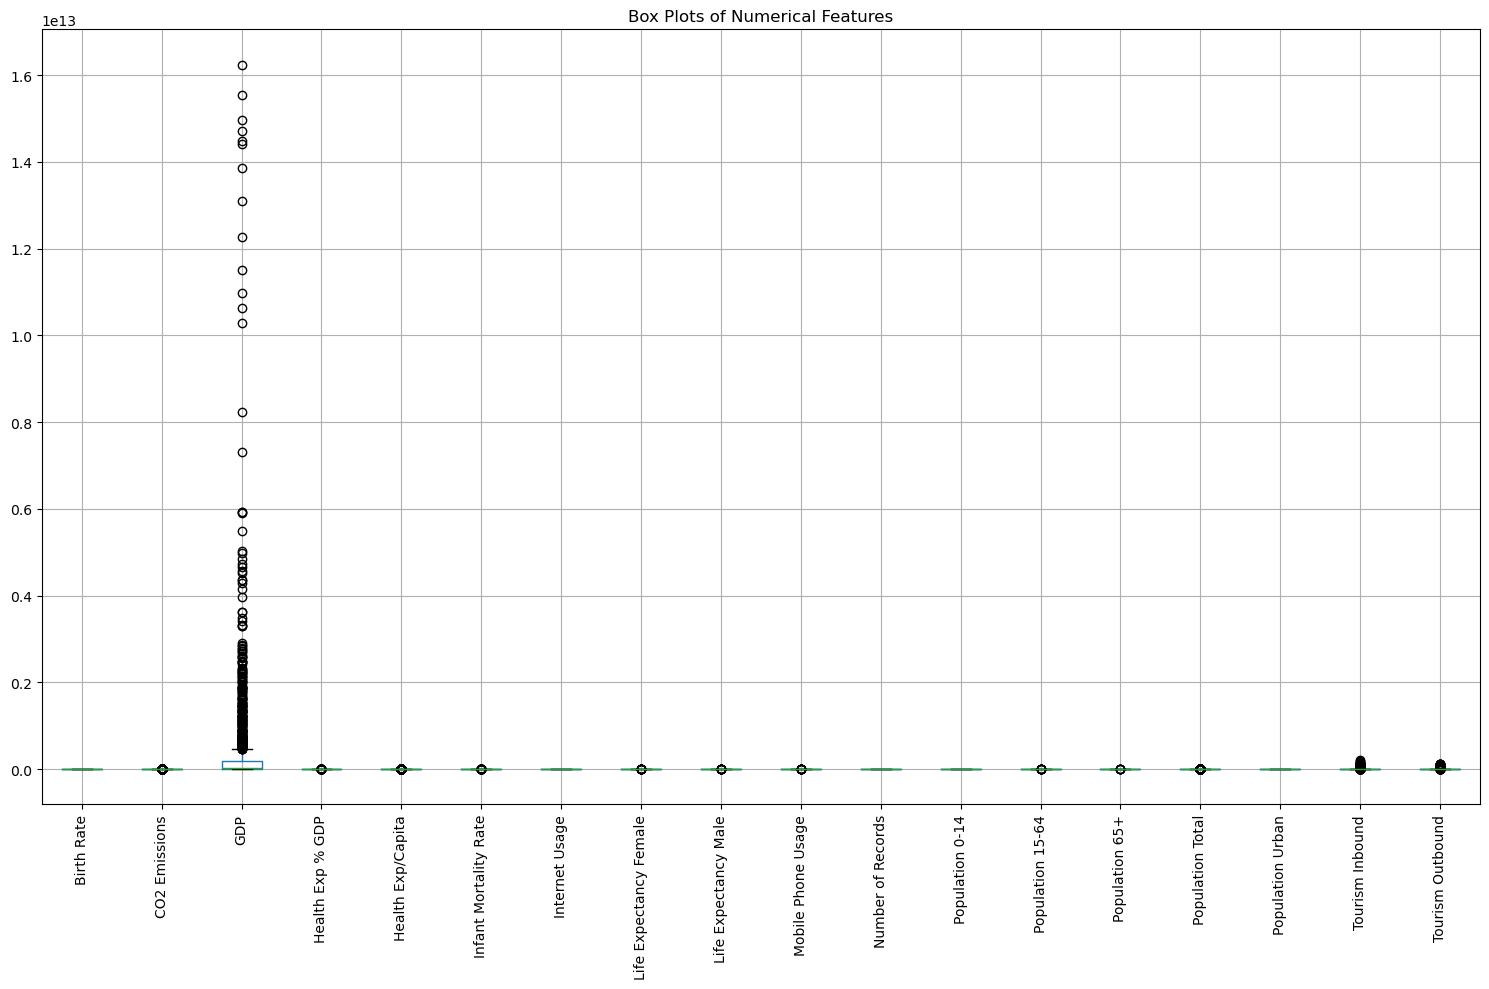

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box Plots of Numerical Features')
plt.tight_layout()
plt.show()

In [16]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

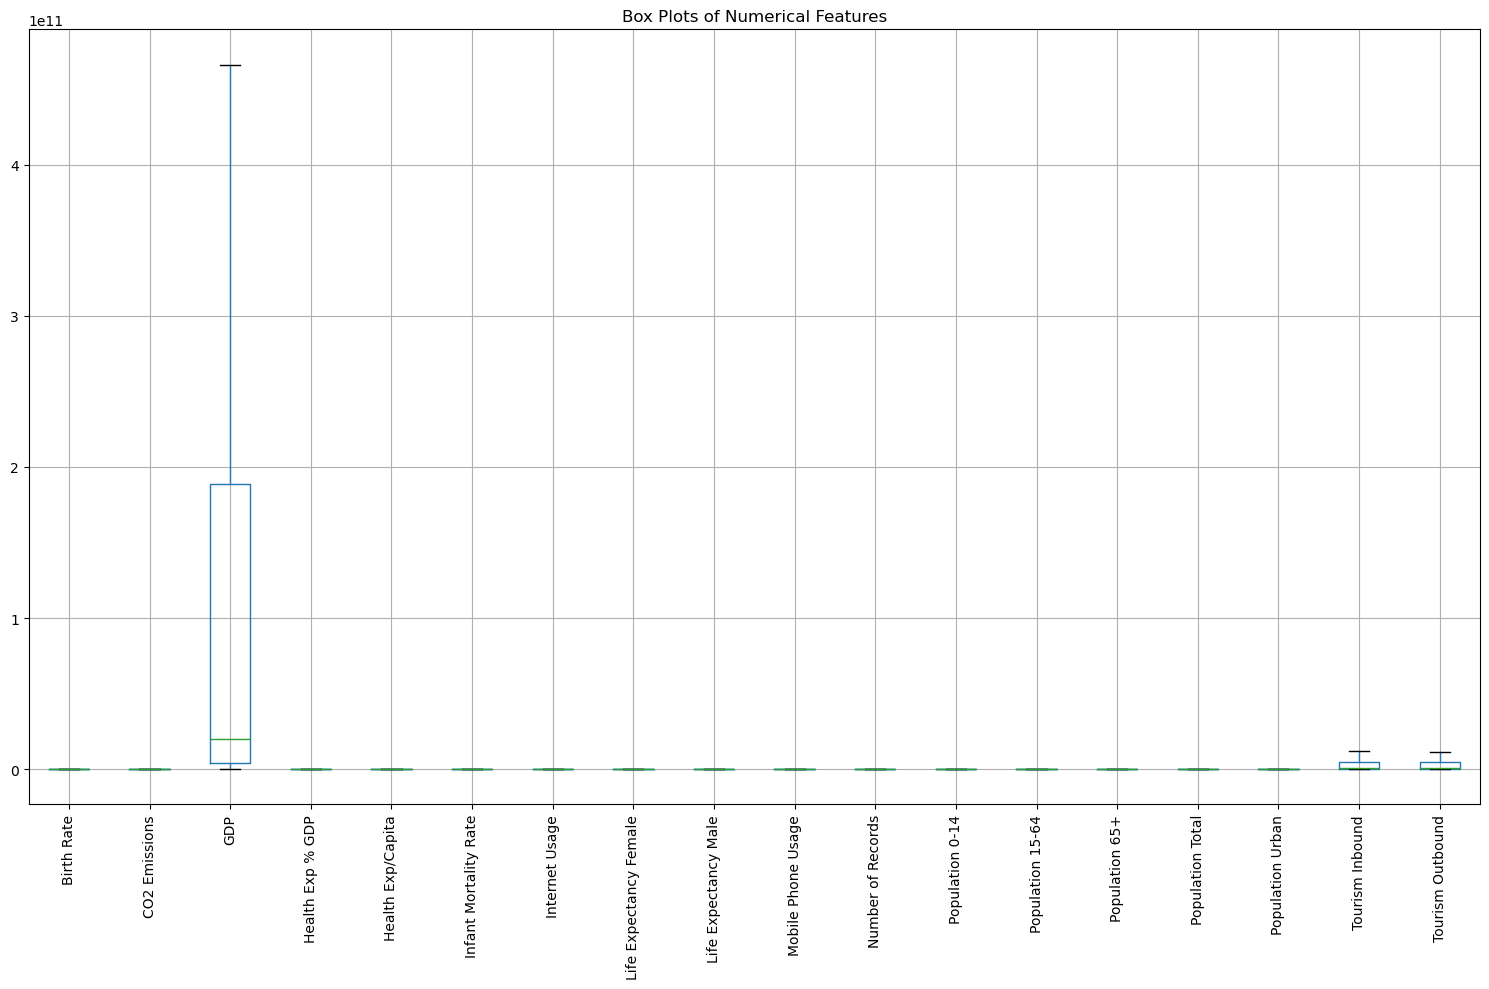

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box Plots of Numerical Features')
plt.tight_layout()
plt.show()

# Data Visualization

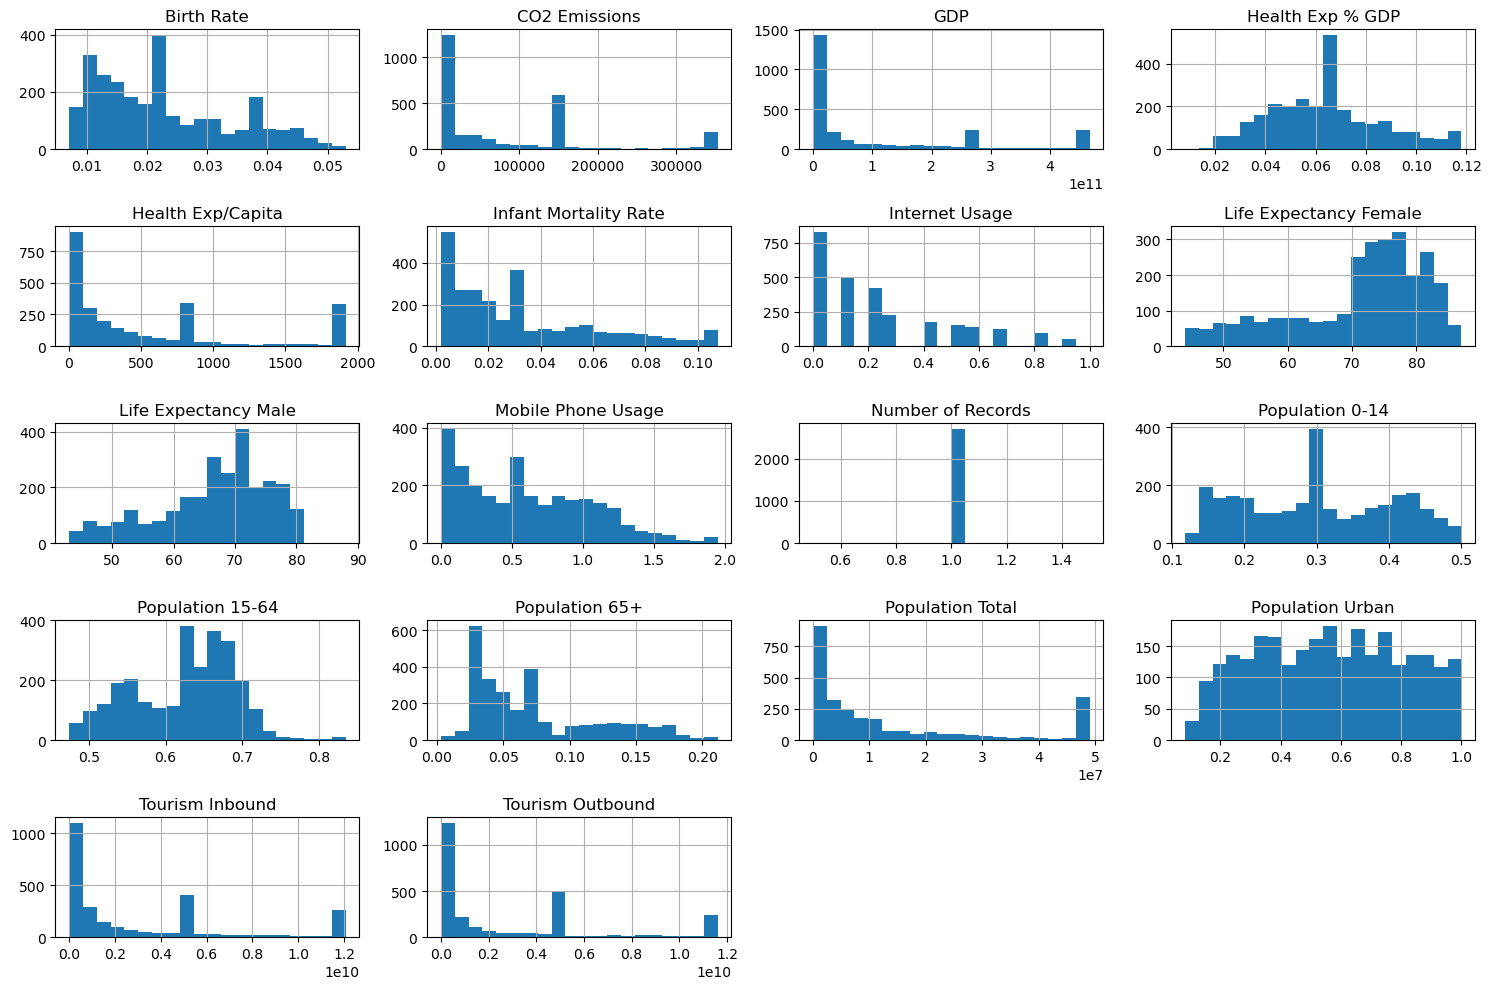

In [18]:
# Plot histograms for numerical columns
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

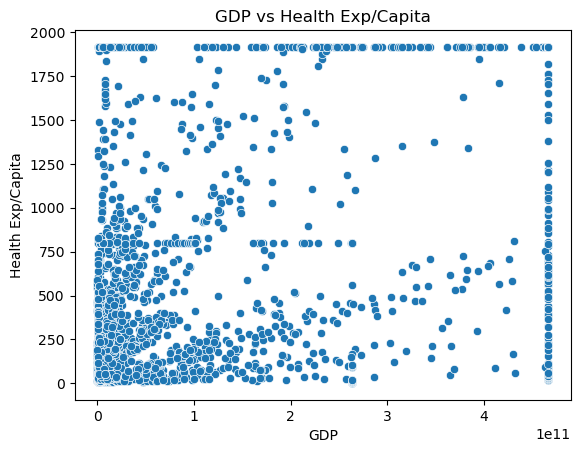

<Figure size 500x500 with 0 Axes>

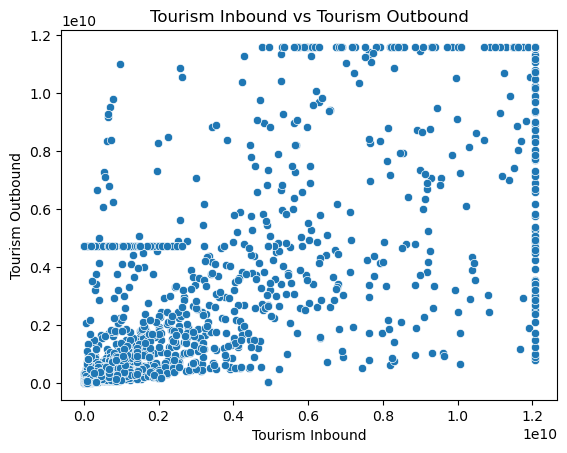

<Figure size 500x500 with 0 Axes>

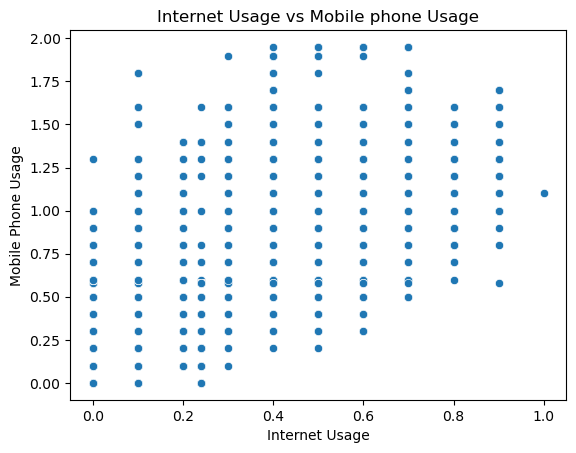

<Figure size 500x500 with 0 Axes>

In [19]:
# scatter plot 
sns.scatterplot(data=df, x='GDP', y='Health Exp/Capita')
plt.title('GDP vs Health Exp/Capita')
plt.xlabel('GDP')
plt.ylabel('Health Exp/Capita')
plt.figure(figsize=(5, 5))
plt.show()

sns.scatterplot(data=df, x='Tourism Inbound', y='Tourism Outbound')
plt.title('Tourism Inbound vs Tourism Outbound')
plt.xlabel('Tourism Inbound')
plt.ylabel('Tourism Outbound')
plt.figure(figsize=(5, 5))
plt.show()

sns.scatterplot(data=df, x='Internet Usage', y='Mobile Phone Usage')
plt.title('Internet Usage vs Mobile phone Usage')
plt.xlabel('Internet Usage')
plt.ylabel('Mobile Phone Usage')
plt.figure(figsize=(5, 5))
plt.show()


In [20]:
##sns.pairplot(df[numerical_cols])

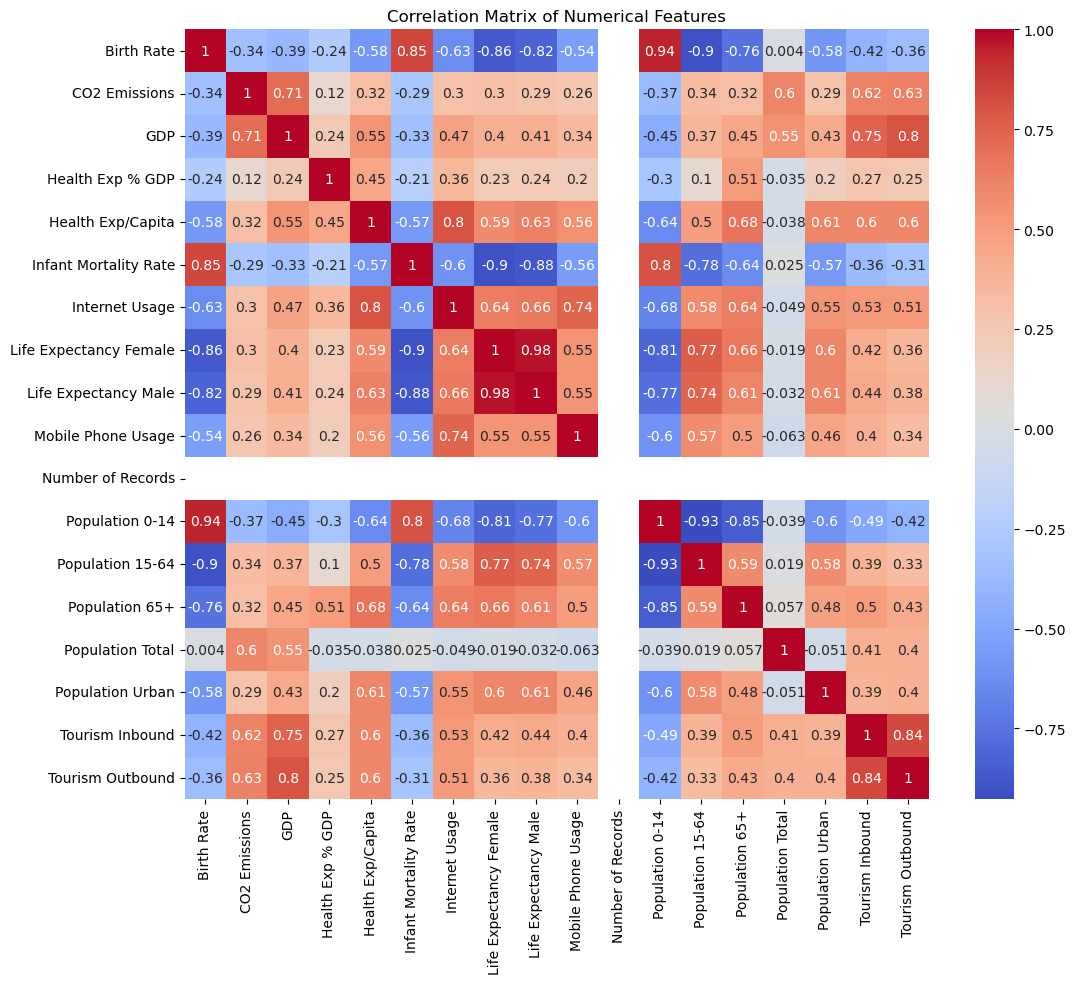

In [21]:
# Calculate and plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Feature Engineering

In [22]:
# generating new features from existing features that are highly corelated
df['Avg_Life_expectancy']=(df['Life Expectancy Female']+df['Life Expectancy Male'])/2
df['Total_Tourism']=df['Tourism Inbound']+df['Tourism Outbound']

In [23]:
#highly corelated columns
df.drop([
    'Life Expectancy Female','Life Expectancy Male','Tourism Inbound','Tourism Outbound'],axis=1,inplace=True)

In [24]:
display(df['Number of Records'].duplicated().sum())

np.int64(2703)

In [25]:
if 'Number of Records' in df.columns:
    df.drop(columns=['Number of Records'], inplace=True)


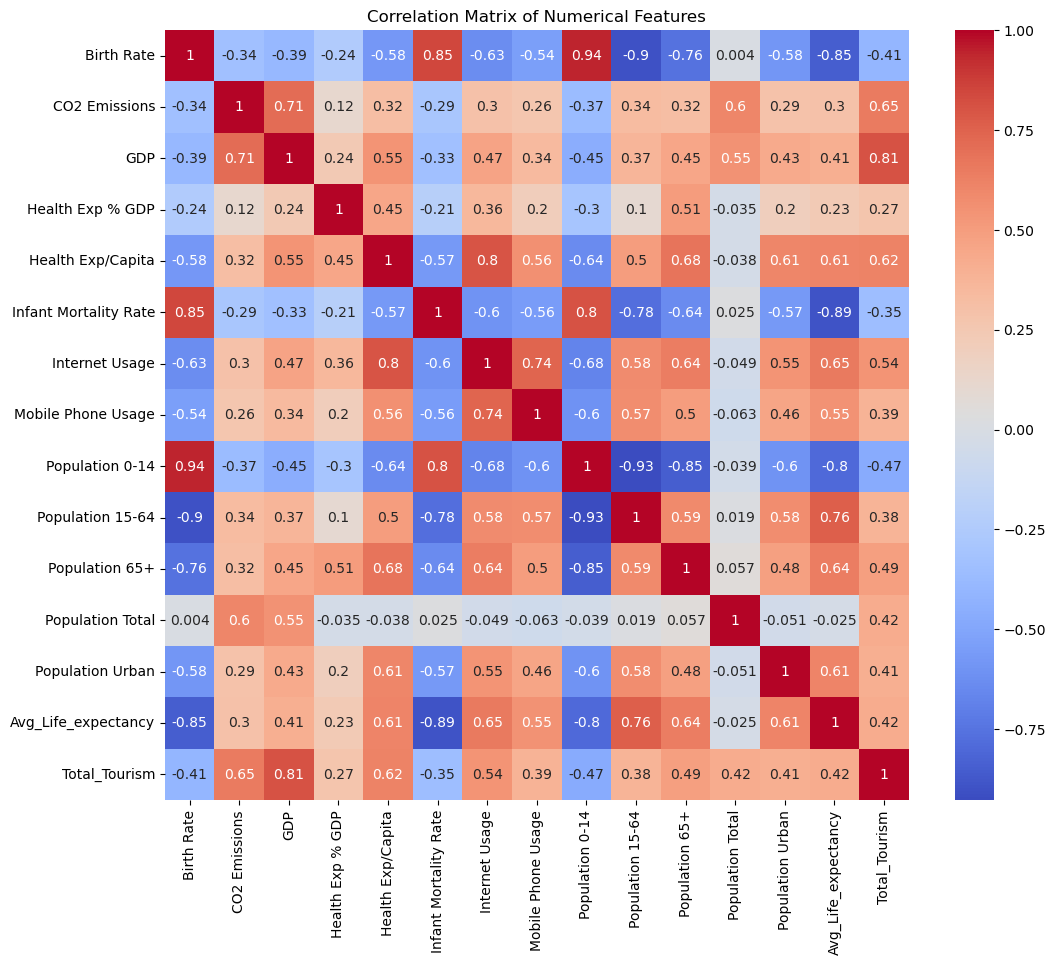

In [26]:
# Calculate and plot the correlation matrix
corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [27]:
df.head()

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Avg_Life_expectancy,Total_Tourism
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,0.619,0.039,31719449.0,0.599,69.0,295000000.0
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,0.499,0.025,13924930.0,0.324,45.5,180000000.0
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,0.517,0.029,6949366.0,0.383,55.0,127000000.0
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,0.587,0.029,1755375.0,0.532,50.5,436000000.0
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,0.505,0.028,11607944.0,0.178,50.5,53000000.0


In [28]:
df.to_csv('clustering_data.csv',index=False)

In [29]:
new_df=pd.read_csv("clustering_data.csv")

In [30]:
numerical_columns = new_df.select_dtypes(include=['float64', 'int64']).columns
display(numerical_columns)

Index(['Birth Rate', 'CO2 Emissions', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Infant Mortality Rate', 'Internet Usage',
       'Mobile Phone Usage', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Avg_Life_expectancy', 'Total_Tourism'],
      dtype='object')

In [31]:
##x = df.drop(columns = ['Country'])
x=new_df[numerical_columns]

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled=scaler.fit_transform(x)


In [33]:
# df.head()

In [34]:
from sklearn.decomposition import PCA #import PCA
pca = PCA(n_components=2)
pcomp = pca.fit_transform(X_scaled) #fit_transform df_scaled using PCA

In [35]:
#col = []
#for i in range(1,21):
   # col.append('PC'+str(i))  #Create Column Names For PCA Components
x_pca=pd.DataFrame(pcomp,columns=['PC1','PC2'])   
#df_pca = pd.DataFrame(pcomp) #Convert PCA Components Into DataFrame With Column Names
#df_pca.head()

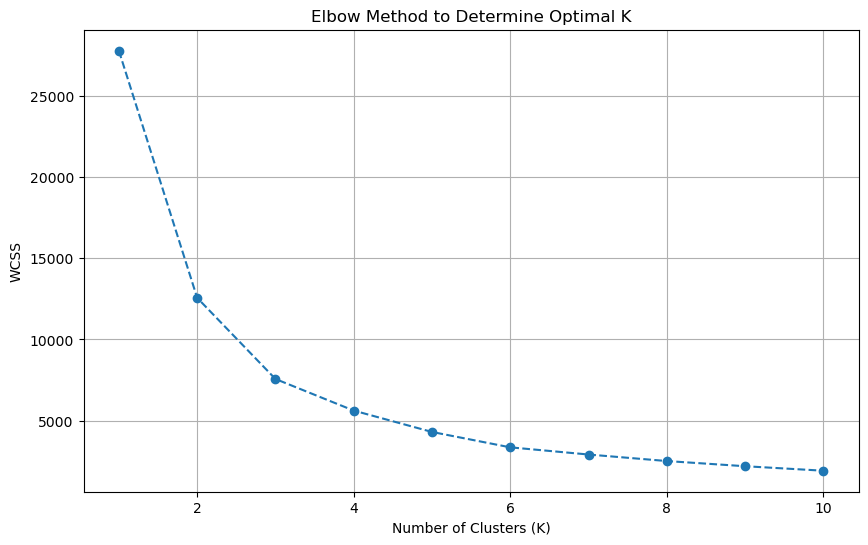

In [36]:
from sklearn.cluster import KMeans
wcss = [] # Within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pcomp)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


silhouette_scores = []
k_values = range(2, 11)  # try K from 2 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pcomp)
    
    score = silhouette_score(pcomp, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4705
K = 3, Silhouette Score = 0.4813
K = 4, Silhouette Score = 0.4173
K = 5, Silhouette Score = 0.4415
K = 6, Silhouette Score = 0.4207
K = 7, Silhouette Score = 0.4258
K = 8, Silhouette Score = 0.4097
K = 9, Silhouette Score = 0.3871
K = 10, Silhouette Score = 0.4079


In [38]:
x_pca.shape


(2704, 2)

In [39]:
optimal_k = 3 # Based on the elbow method from the plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(x_pca)

df['cluster']=kmeans.predict(x_pca)
df['PC1'] = x_pca['PC1']
df['PC2'] = x_pca['PC2']
##df['Cluster'] = clusters
df.head()

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Avg_Life_expectancy,Total_Tourism,cluster,PC1,PC2
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,0.619,0.039,31719449.0,0.599,69.0,295000000.0,0,1.439320,0.401193
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,0.499,0.025,13924930.0,0.324,45.5,180000000.0,0,5.396880,1.058750
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,0.517,0.029,6949366.0,0.383,55.0,127000000.0,0,4.475406,0.329005
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,0.587,0.029,1755375.0,0.532,50.5,436000000.0,0,2.948168,-0.481228
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,0.505,0.028,11607944.0,0.178,50.5,53000000.0,0,5.020623,0.730898


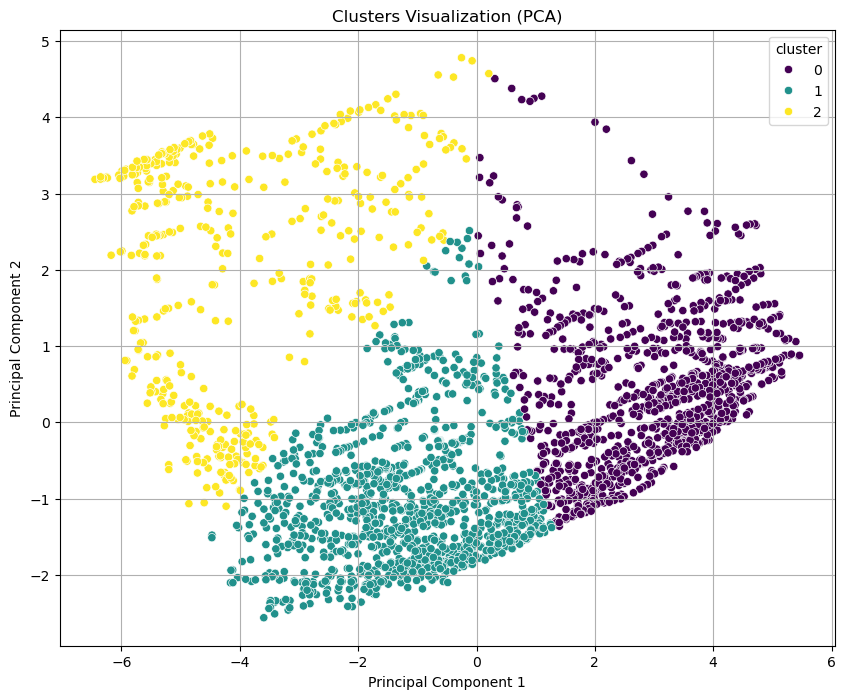

In [40]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pcomp[:, 0], y=pcomp[:, 1], hue=df['cluster'], palette='viridis', legend='full')
plt.title('Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(x_pca,df['cluster'])
print(f"The average Silhouette Score for the clusters is: {silhouette_avg:.3f}")

The average Silhouette Score for the clusters is: 0.481


In [42]:
# hierarchial

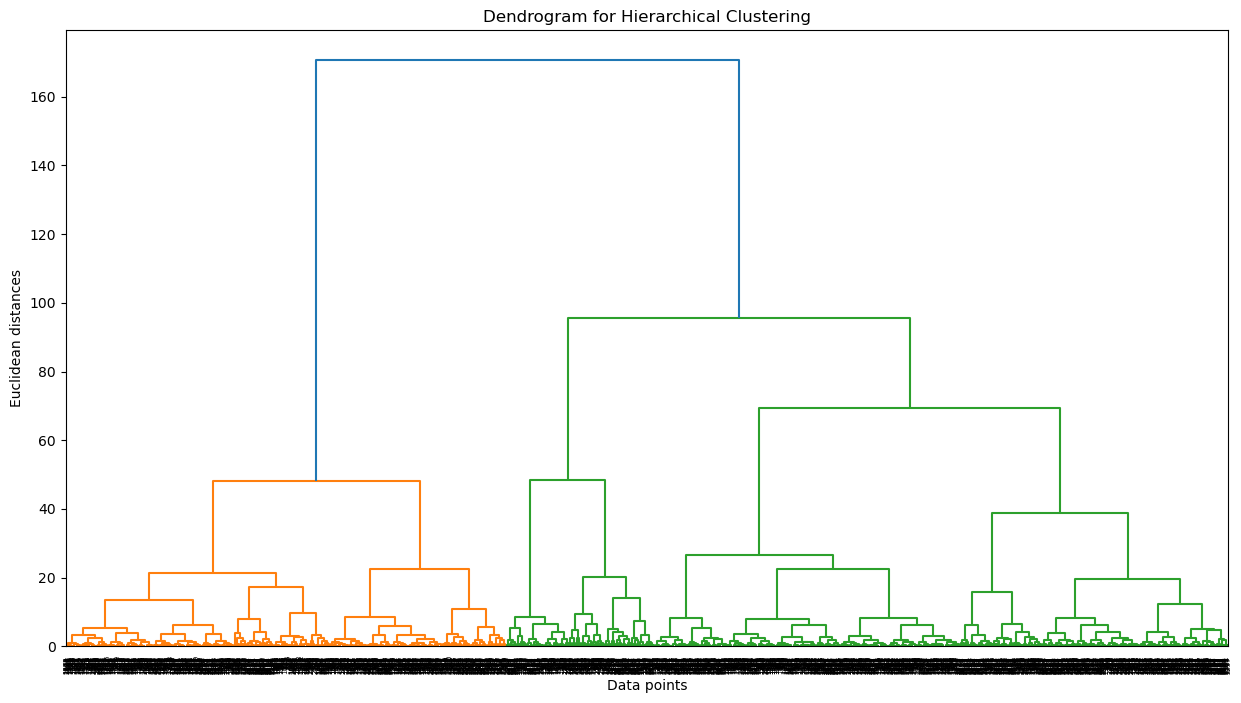

In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(15, 8))
dendro = dendrogram(linkage(x_pca, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data points')
plt.ylabel('Euclidean distances')
plt.show()

In [44]:
from sklearn.cluster import AgglomerativeClustering

# Choosing 3 clusters based on visual inspection of the dendrogram
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_clusters = hierarchical_model.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hierarchical_clusters

display(df.head())

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Avg_Life_expectancy,Total_Tourism,cluster,PC1,PC2,Hierarchical_Cluster
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,0.619,0.039,31719449.0,0.599,69.0,295000000.0,0,1.439320,0.401193,0
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,0.499,0.025,13924930.0,0.324,45.5,180000000.0,0,5.396880,1.058750,1
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,0.517,0.029,6949366.0,0.383,55.0,127000000.0,0,4.475406,0.329005,1
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,0.587,0.029,1755375.0,0.532,50.5,436000000.0,0,2.948168,-0.481228,1
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,0.505,0.028,11607944.0,0.178,50.5,53000000.0,0,5.020623,0.730898,1


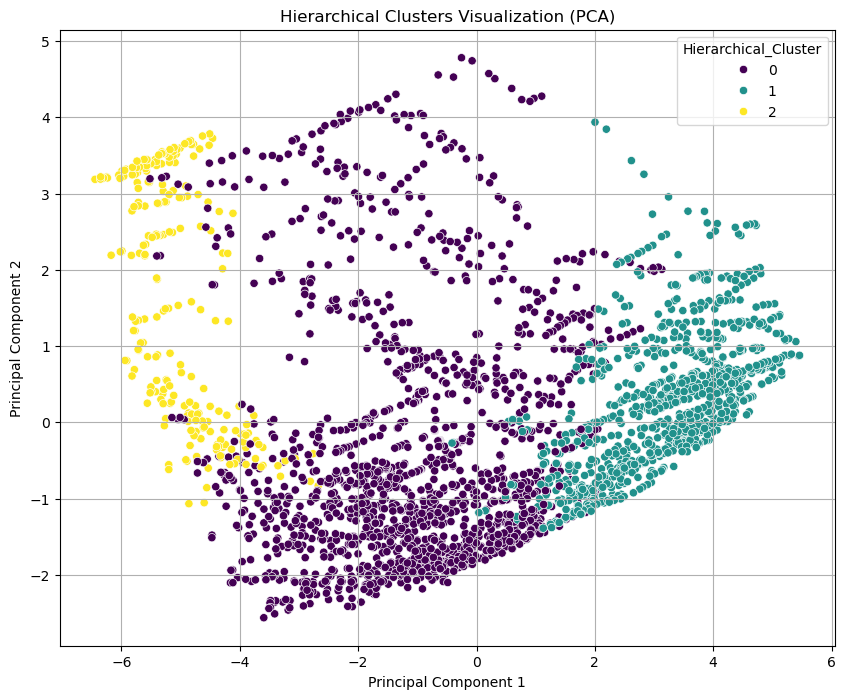

In [45]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pcomp[:, 0], y=pcomp[:, 1], hue=df['Hierarchical_Cluster'], palette='viridis', legend='full')
plt.title('Hierarchical Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import silhouette_score

silhouette_avg_hierarchical = silhouette_score(pcomp, hierarchical_clusters)
print(f"The average Silhouette Score for Hierarchical Clusters is: {silhouette_avg_hierarchical:.3f}")

The average Silhouette Score for Hierarchical Clusters is: 0.379


In [47]:
#DBSCAN 
print(pcomp.shape)

(2704, 2)


In [48]:
#scaler = StandardScaler()
#pcomp_scaled = scaler.fit_transform(pcomp)

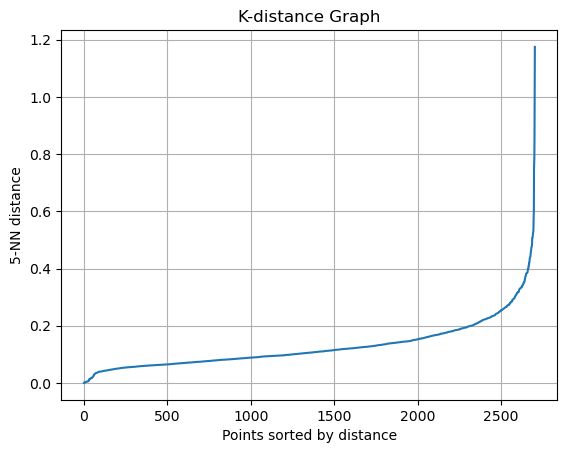

In [49]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Choose k = min_samples (we'll decide below, use a guess first like 5)
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(pcomp)

distances, indices = neighbors_fit.kneighbors(pcomp)

# sort distances (take kth neighbor distance)
distances = np.sort(distances[:, k-1])

plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-NN distance')
plt.title('K-distance Graph')
plt.grid()
plt.show()

In [50]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
# Choosing initial parameters, these may need tuning for optimal results
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(pcomp)

df['DBSCAN_Cluster'] = dbscan_clusters

display(df.head())

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,...,Population 65+,Population Total,Population Urban,Avg_Life_expectancy,Total_Tourism,cluster,PC1,PC2,Hierarchical_Cluster,DBSCAN_Cluster
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,...,0.039,31719449.0,0.599,69.0,295000000.0,0,1.439320,0.401193,0,0
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,...,0.025,13924930.0,0.324,45.5,180000000.0,0,5.396880,1.058750,1,0
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,...,0.029,6949366.0,0.383,55.0,127000000.0,0,4.475406,0.329005,1,0
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,...,0.029,1755375.0,0.532,50.5,436000000.0,0,2.948168,-0.481228,1,0
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,...,0.028,11607944.0,0.178,50.5,53000000.0,0,5.020623,0.730898,1,0


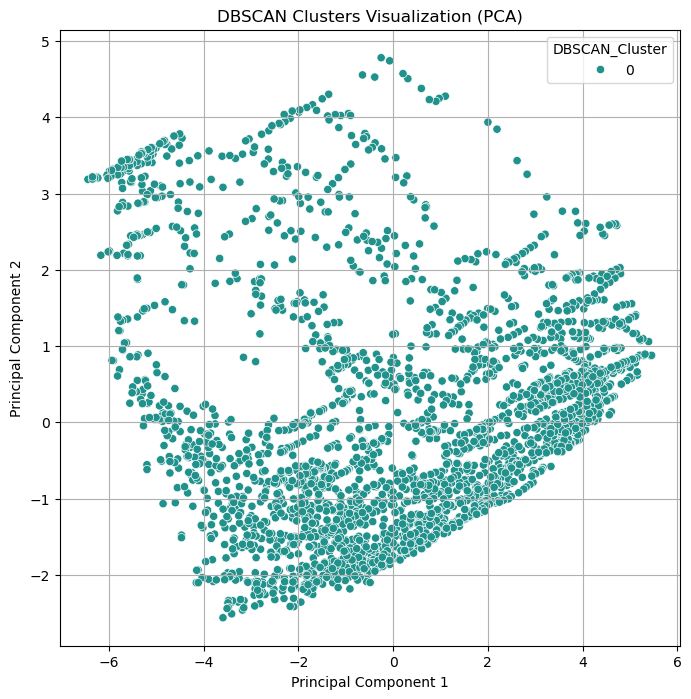

In [51]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=pcomp[:, 0], y=pcomp[:, 1], hue=df['DBSCAN_Cluster'], palette='viridis', legend='full')
plt.title('DBSCAN Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [52]:
from sklearn.metrics import silhouette_score

# Silhouette Score for DBSCAN (excluding noise points if any)
# Noise points are labeled as -1 by DBSCAN
if len(set(dbscan_clusters)) > 1:
    # Only calculate if there are actual clusters (more than just noise)
    silhouette_avg_dbscan = silhouette_score(pcomp[dbscan_clusters != -1], dbscan_clusters[dbscan_clusters != -1])
    print(f"The average Silhouette Score for DBSCAN Clusters is: {silhouette_avg_dbscan:.3f}")
else:
    print("DBSCAN found no clusters (all points are noise or in a single cluster).")
    silhouette_avg_dbscan = np.nan 

DBSCAN found no clusters (all points are noise or in a single cluster).


In [53]:
#guassian mixture

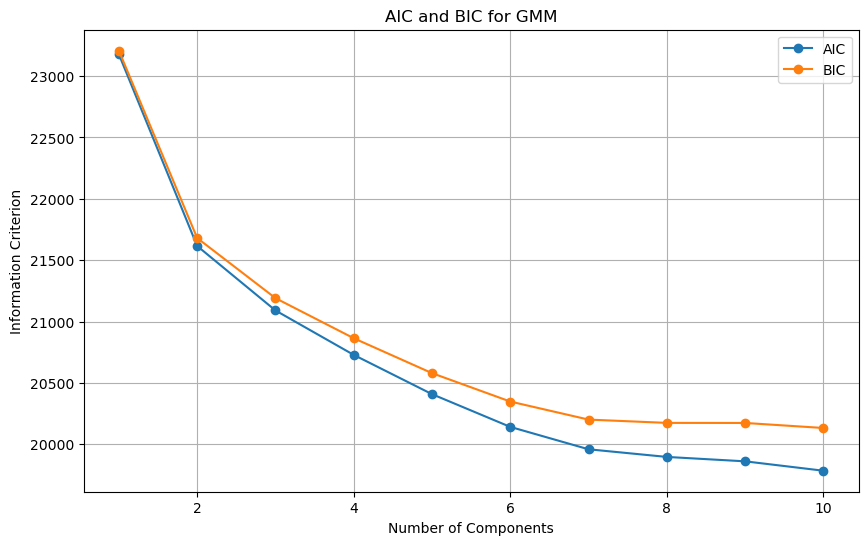

In [54]:
from sklearn.mixture import GaussianMixture

# Range of clusters to test
n_components = range(1, 11)

aic = []
bic = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(pcomp)
    aic.append(gmm.aic(pcomp))
    bic.append(gmm.bic(pcomp))

plt.figure(figsize=(10, 6))
plt.plot(n_components, aic, label='AIC', marker='o')
plt.plot(n_components, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC for GMM')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# Based on BIC/AIC, let's choose an optimal number of components
optimal_gmm_components = 3

gmm = GaussianMixture(n_components=optimal_gmm_components, random_state=42)
gmm_clusters = gmm.fit_predict(pcomp)

df['GMM_Cluster'] = gmm_clusters

display(df.head())

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,...,Population Total,Population Urban,Avg_Life_expectancy,Total_Tourism,cluster,PC1,PC2,Hierarchical_Cluster,DBSCAN_Cluster,GMM_Cluster
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,...,31719449.0,0.599,69.0,295000000.0,0,1.439320,0.401193,0,0,0
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,...,13924930.0,0.324,45.5,180000000.0,0,5.396880,1.058750,1,0,0
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,...,6949366.0,0.383,55.0,127000000.0,0,4.475406,0.329005,1,0,0
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,...,1755375.0,0.532,50.5,436000000.0,0,2.948168,-0.481228,1,0,0
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,...,11607944.0,0.178,50.5,53000000.0,0,5.020623,0.730898,1,0,0


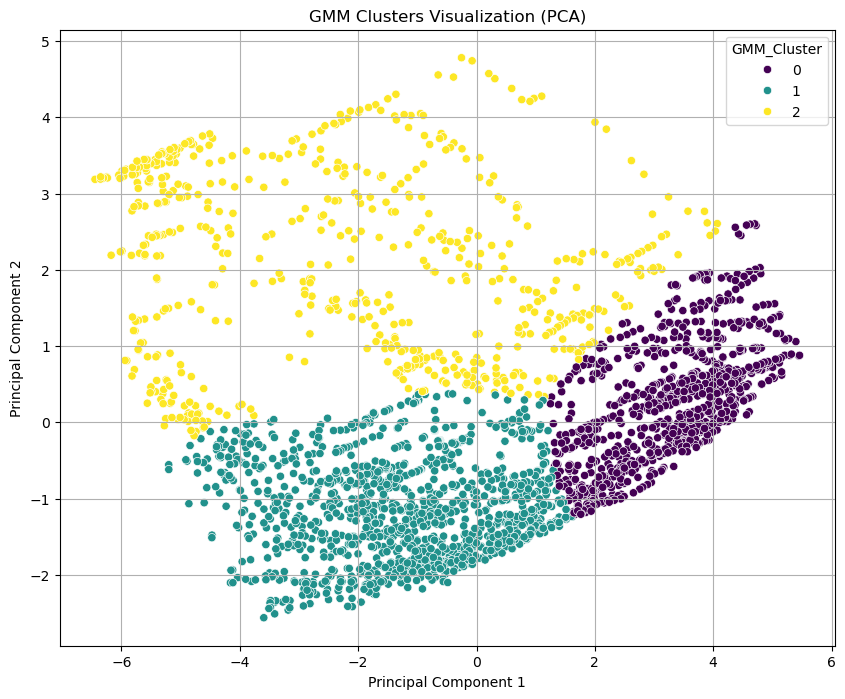

In [56]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pcomp[:, 0], y=pcomp[:, 1], hue=df['GMM_Cluster'], palette='viridis', legend='full')
plt.title('GMM Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [57]:
from sklearn.metrics import silhouette_score

silhouette_avg_gmm = silhouette_score(pcomp, gmm_clusters)
print(f"The average Silhouette Score for GMM Clusters is: {silhouette_avg_gmm:.3f}")

The average Silhouette Score for GMM Clusters is: 0.425


In [58]:
# mean shift

In [59]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Estimate bandwidth for MeanShift
bandwidth = estimate_bandwidth(pcomp, quantile=0.2, n_samples=300)

# Apply MeanShift clustering
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift_clusters = ms.fit_predict(pcomp)

df['MeanShift_Cluster'] = meanshift_clusters

display(df.head())

,Birth Rate,CO2 Emissions,Country,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Mobile Phone Usage,Population 0-14,...,Population Urban,Avg_Life_expectancy,Total_Tourism,cluster,PC1,PC2,Hierarchical_Cluster,DBSCAN_Cluster,GMM_Cluster,MeanShift_Cluster
0,0.020,87931.0,Algeria,5.479006e+10,0.035,60.0,0.0340,0.0,0.0,0.342,...,0.599,69.0,295000000.0,0,1.439320,0.401193,0,0,0,1
1,0.050,9542.0,Angola,9.129595e+09,0.034,22.0,0.1075,0.0,0.0,0.476,...,0.324,45.5,180000000.0,0,5.396880,1.058750,1,0,0,1
2,0.043,1617.0,Benin,2.359122e+09,0.043,15.0,0.0900,0.0,0.0,0.454,...,0.383,55.0,127000000.0,0,4.475406,0.329005,1,0,0,1
3,0.027,4276.0,Botswana,5.788312e+09,0.047,152.0,0.0540,0.0,0.1,0.383,...,0.532,50.5,436000000.0,0,2.948168,-0.481228,1,0,0,1
4,0.046,1041.0,Burkina Faso,2.610959e+09,0.051,12.0,0.0960,0.0,0.0,0.468,...,0.178,50.5,53000000.0,0,5.020623,0.730898,1,0,0,1


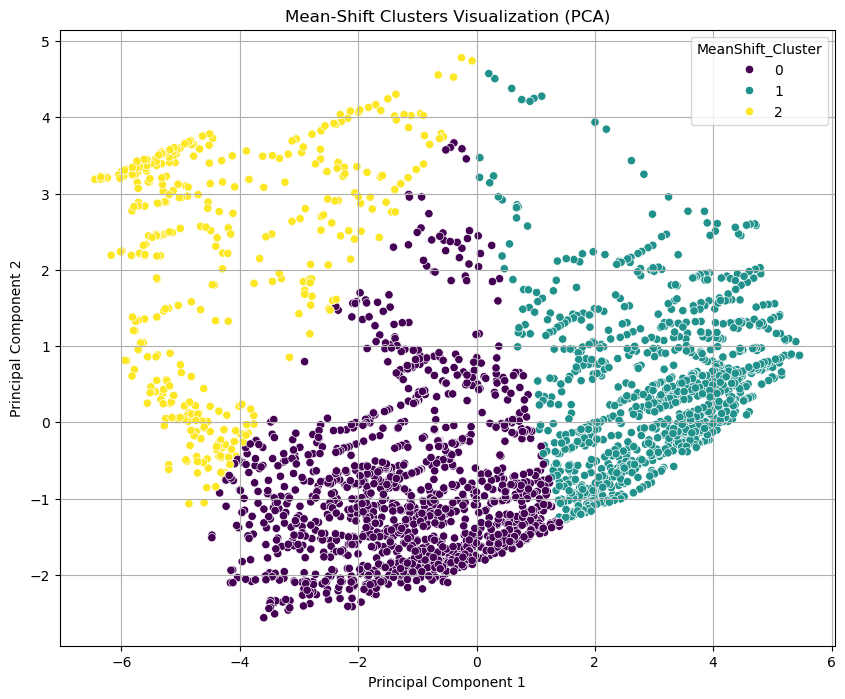

In [60]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pcomp[:, 0], y=pcomp[:, 1], hue=df['MeanShift_Cluster'], palette='viridis', legend='full')
plt.title('Mean-Shift Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [61]:
from sklearn.metrics import silhouette_score

# Silhouette Score for Mean-Shift
# Only calculate if there are actual clusters (more than one unique label, excluding -1 if present)
if len(set(meanshift_clusters)) > 1:
    silhouette_avg_meanshift = silhouette_score(pcomp, meanshift_clusters)
    print(f"The average Silhouette Score for Mean-Shift Clusters is: {silhouette_avg_meanshift:.3f}")
else:
    print("Mean-Shift found no distinct clusters or only a single cluster.")
    silhouette_avg_meanshift = np.nan 

The average Silhouette Score for Mean-Shift Clusters is: 0.481


In [62]:
comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM','Mean shift'],
    'Silhouette Score': [
        silhouette_avg, # From K-Means
        silhouette_avg_hierarchical, # From Hierarchical Clustering
        silhouette_avg_dbscan, # From DBSCAN
        silhouette_avg_gmm,# From GMM
        silhouette_avg_meanshift,
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df.sort_values(by='Silhouette Score', ascending=False))

,Algorithm,Silhouette Score
0,K-Means,0.481325
4,Mean shift,0.480591
3,GMM,0.425419
1,Hierarchical,0.379453
2,DBSCAN,NaN


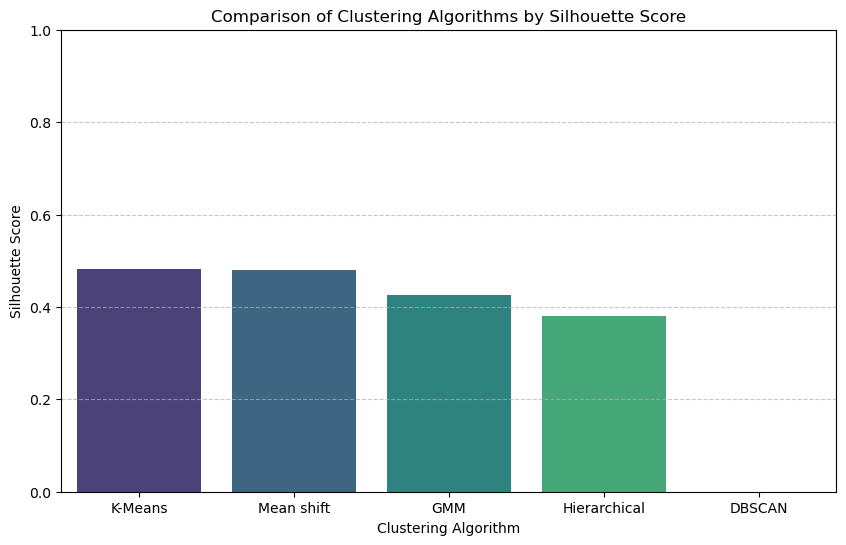

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Silhouette Score', data=comparison_df.sort_values(by='Silhouette Score', ascending=False), palette='viridis')
plt.title('Comparison of Clustering Algorithms by Silhouette Score')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette Score ranges from -1 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pcomp, kmeans.labels_)

accuracy_like = ((score + 1) / 2) * 100

print(accuracy_like)

74.06623030163163


In [65]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(pcomp, df['cluster'])
accuracy_like = ((sil_score + 1) / 2) * 100

display(f"Silhouette Score: {sil_score:.3f}")
display(f"Clustering Quality: {accuracy_like:.2f}%")

'Silhouette Score: 0.481'

'Clustering Quality: 74.07%'

In [66]:
#deployment

In [67]:
import joblib

In [68]:
joblib.dump(scaler,"clustering_scaler.pkl")

['clustering_scaler.pkl']

In [69]:
joblib.dump(pca,"clustering_pca.pkl")

['clustering_pca.pkl']

In [70]:
joblib.dump(kmeans,"clustering_kmeans.pkl")

['clustering_kmeans.pkl']

In [71]:
joblib.dump(numerical_columns, "features.pkl")

['features.pkl']